In [6]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json

In [7]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/Old_data/total_mzcounts_sorted.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/Old output (pkl)/TDM_old_T1_varyinflux.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/new_mzontogeny.fitall.varyinflux.T1.pkl'
# if os.path.getsize(file_path) > 0:
#     with open(file_path, 'rb') as f:
#         data_fitall = pkl.load(f)
# else:
#     raise EOFError("File is empty")
# #Open json file
# with open('/home/apoorva/Desktop/work/MZ_analysis/data/Mz_ontogenyT1.varyinginflux.json') as f:
#     data = json.load(f)

/tmp/ipykernel_1604218/1648362380.py:17: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


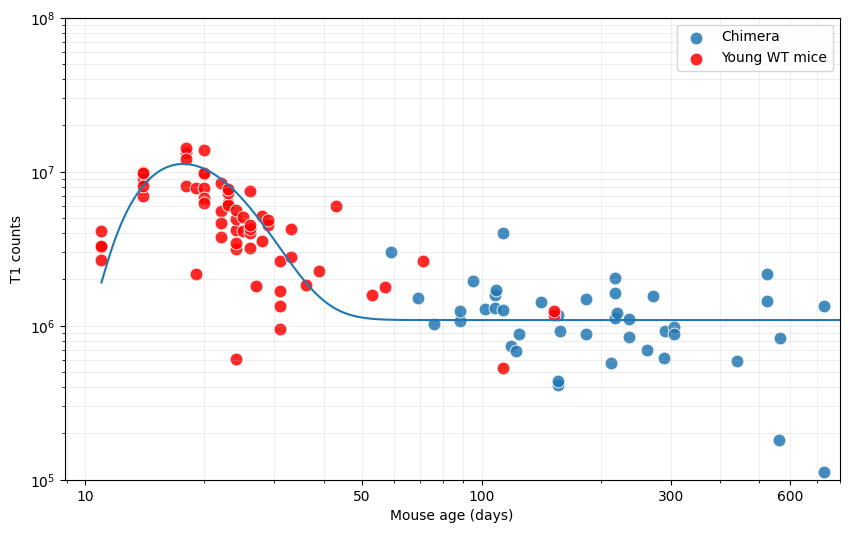

In [10]:
def P(t):
    theta_0 = np.exp(13.9)
    nu = 0.28
    n = 2.15
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='age.at.S1K', y='total_Transitional1_AA4.1', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T1 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [11]:
def P(t):
    # theta_0 = np.exp(14.17)
    # nu = 0.31
    # n = 1.98
    theta_0 = np.exp(13.9)
    nu = 0.28
    n = 2.15
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = data_neutral.stan_variable('r_d')  # Extract 'r_d' from CmdStanMCMC object
    phi = data_neutral.stan_variable('phi')  # Extract 'phi' from CmdStanMCMC object
    phi_var = phi / (1 + np.exp(-r_phi * (t - 30)))
    # phi_var = phi * np.exp(-r_phi * (t - 40))
    return phi_var

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi(t) * P(t) + rho* M - delta * M
    return np.array(dMdt) 


# Define the parameters as array
# lamda = np.mean(data_neutral.delta) - np.mean(data_neutral.rho)
rho = data_neutral.rho
delta = data_neutral.delta
print("rphi", np.mean(data_neutral.r_d))


#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi_values = data_neutral.stan_variable('phi')  # Extract 'phi' values from CmdStanMCMC object
r_phi_values = data_neutral.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object

sol = np.zeros((len(phi_values), len(t_ev)))
for i in range(len(phi_values)):
    def phi_func(t):
        return phi_values[i] / (1 + np.exp(-r_phi_values[i] * (t - 30)))
    
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi_func, rho[i], delta[i], P))
    sol[i, :] = result.y[0]

# sol = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta, P))
# print(sol.y)

# sol = np.zeros((len(data_neutral.phi), len(t_ev)))
# for i in range(len(data_neutral.phi)):
#     result = solve_ivp(ode_function, [40, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
#     sol[i, :] = result.y[0]

# print(sol.shape)
# print(M0)



rphi 0.036407985946666666


/tmp/ipykernel_1604218/3737667545.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


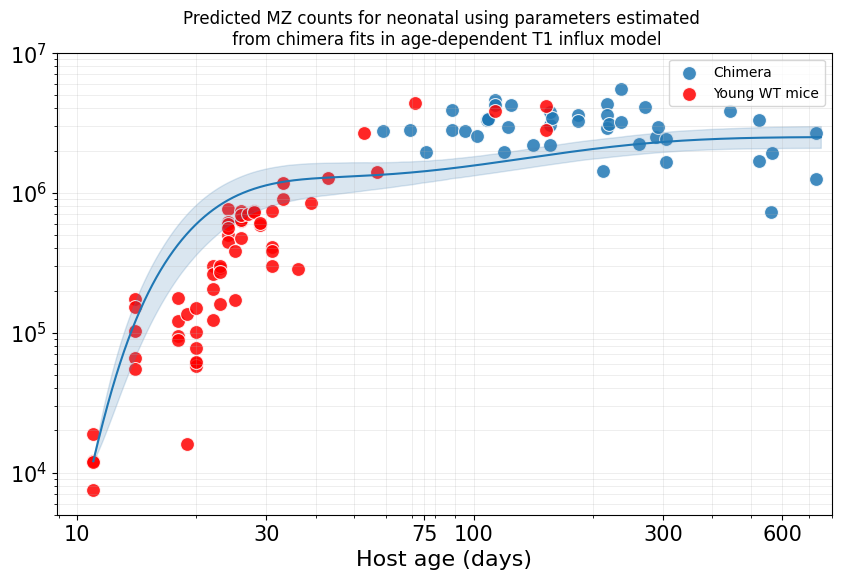

In [12]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new,  x='age.at.S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol, axis=0))
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T1 influx model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()